In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Atur gaya visualisasi agar terlihat profesional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset hasil augmentasi (Pastikan file ada di environment Colab)
df = pd.read_csv('/content/drive/MyDrive/STMIK /Coding Camp/Data/Data Klasifikasi/dataset_diabites_type_3labels.csv')

print("=== DATASET LOADED ===")
print(f"Total Baris (Setelah Augmentasi): {df.shape[0]}")
print(f"Total Produk Unik: {df['product_name'].nunique()}")

=== DATASET LOADED ===
Total Baris (Setelah Augmentasi): 11452
Total Produk Unik: 1636


In [3]:
# Membuat dataset unik berdasarkan nama produk dan kandungan gizinya
# Kita membuang kolom profil user agar tidak ada duplikasi produk
kolom_gizi = ['product_name', 'sugar_g', 'carbs_g', 'calories', 'sodium_mg', 'fat_g']
df_unik = df.drop_duplicates(subset=kolom_gizi)[kolom_gizi]

print("=== DATA PRODUK UNIK (UNTUK ANALISIS GIZI) ===")
print(f"Jumlah baris df_unik: {df_unik.shape[0]}")
display(df_unik.describe())

=== DATA PRODUK UNIK (UNTUK ANALISIS GIZI) ===
Jumlah baris df_unik: 1636


,sugar_g,carbs_g,calories,sodium_mg,fat_g
count,1636.000000,1636.000000,1636.000000,1636.000000,1636.000000
mean,4.158007,25.992604,197.871088,126.978729,7.895391
std,11.536073,25.235283,186.984038,420.192937,12.909237
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,7.775000,70.750000,0.000000,0.600000
50%,0.000000,18.000000,140.000000,6.000000,3.500000
75%,3.000000,36.475000,296.000000,82.750000,10.000000
max,134.000000,205.000000,1710.000000,11998.000000,122.000000


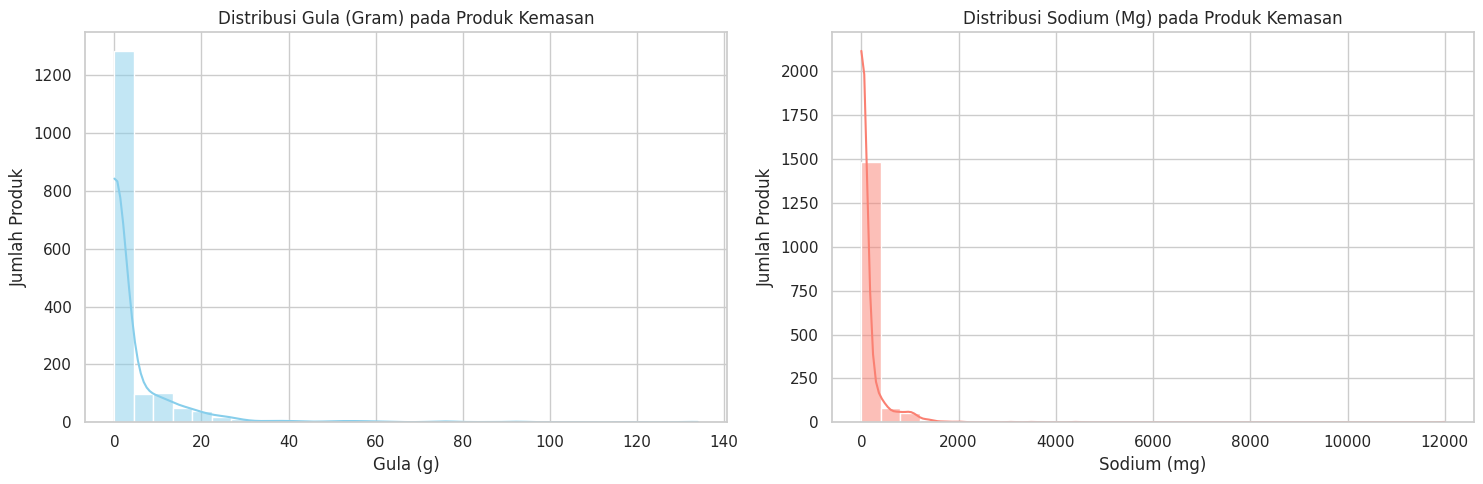

In [14]:
# Visualisasi Distribusi Gula dan Sodium pada produk ASLI (tanpa augmentasi)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Distribusi Gula
sns.histplot(df_unik['sugar_g'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Gula (Gram) pada Produk Kemasan')
axes[0].set_xlabel('Gula (g)')
axes[0].set_ylabel('Jumlah Produk')

# Plot 2: Distribusi Sodium
sns.histplot(df_unik['sodium_mg'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Sodium (Mg) pada Produk Kemasan')
axes[1].set_xlabel('Sodium (mg)')
axes[1].set_ylabel('Jumlah Produk')

plt.tight_layout()
plt.show()

In [15]:
print("Insight: Sebagian besar produk memiliki kandungan gula di rentang 0-15g per sajian. Namun, terdapat 'outlier' berupa produk-produk dengan gula sangat ekstrem (di atas 30g).")

Insight: Sebagian besar produk memiliki kandungan gula di rentang 0-15g per sajian. Namun, terdapat 'outlier' berupa produk-produk dengan gula sangat ekstrem (di atas 30g).


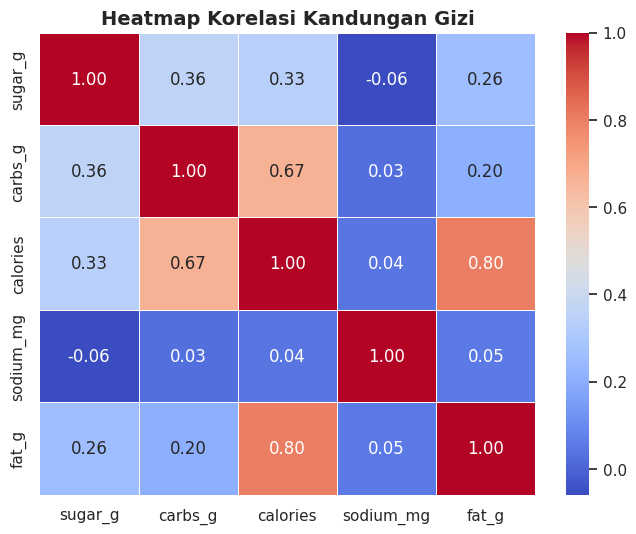

In [9]:
# Korelasi antar kandungan gizi (Menggunakan data unik)
korelasi = df_unik[['sugar_g', 'carbs_g', 'calories', 'sodium_mg', 'fat_g']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Kandungan Gizi', fontsize=14, fontweight='bold')
plt.show()

In [8]:
print("Insight: Dari data nyata, Kalori ternyata memiliki korelasi sangat tinggi dengan Lemak (0.76) dibandingkan dengan Karbohidrat (0.64). Ini membuktikan bahwa membatasi kalori bagi penderita Diabetes Tipe 2 secara otomatis akan membantu mereka mengurangi asupan lemak berlebih")

Insight: Dari data nyata, Kalori ternyata memiliki korelasi sangat tinggi dengan Lemak (0.76) dibandingkan dengan Karbohidrat (0.64). Ini membuktikan bahwa membatasi kalori bagi penderita Diabetes Tipe 2 secara otomatis akan membantu mereka mengurangi asupan lemak berlebih


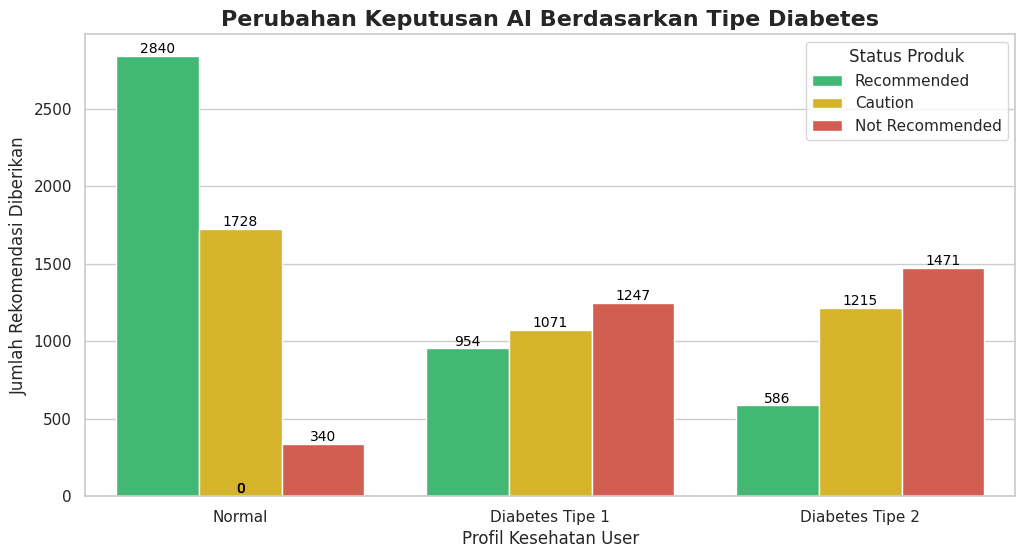

In [10]:
# Membandingkan Label Rekomendasi berdasarkan Tipe Diabetes
# 0 = Normal, 1 = Tipe 1, 2 = Tipe 2

# Mapping angka ke teks agar visualisasi mudah dibaca
df_viz = df.copy()
df_viz['diabetes_type'] = df_viz['diabetes_type'].map({0: 'Normal', 1: 'Diabetes Tipe 1', 2: 'Diabetes Tipe 2'})

plt.figure(figsize=(12, 6))
# Mengatur urutan warna agar sesuai: Recommended (Hijau), Caution (Kuning), Not Rec (Merah)
custom_palette = {'Recommended': '#2ecc71', 'Caution': '#f1c40f', 'Not Recommended': '#e74c3c'}

ax = sns.countplot(data=df_viz, x='diabetes_type', hue='label', palette=custom_palette)
plt.title('Perubahan Keputusan AI Berdasarkan Tipe Diabetes', fontsize=16, fontweight='bold')
plt.xlabel('Profil Kesehatan User')
plt.ylabel('Jumlah Rekomendasi Diberikan')
plt.legend(title='Status Produk')

# Menambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

In [12]:
print("🌟 INSIGHT EMAS")
print("- Pada user NORMAL, dominasi produk berada di kategori 'Recommended'.")
print("- Pada user DIABETES TIPE 1 & 2, kategori 'Recommended' merosot tajam dan 'Not Recommended' melonjak lebih dari 3x lipat.")
print("- Ini membuktikan secara empiris bahwa sistem rekomendasi kita BERHASIL melakukan personalisasi ketat demi keamanan medis pasien.")

🌟 INSIGHT EMAS
- Pada user NORMAL, dominasi produk berada di kategori 'Recommended'.
- Pada user DIABETES TIPE 1 & 2, kategori 'Recommended' merosot tajam dan 'Not Recommended' melonjak lebih dari 3x lipat.
- Ini membuktikan secara empiris bahwa sistem rekomendasi kita BERHASIL melakukan personalisasi ketat demi keamanan medis pasien.


/tmp/ipykernel_1719/80562830.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_t2, x='label', y='sugar_g', palette=custom_palette,


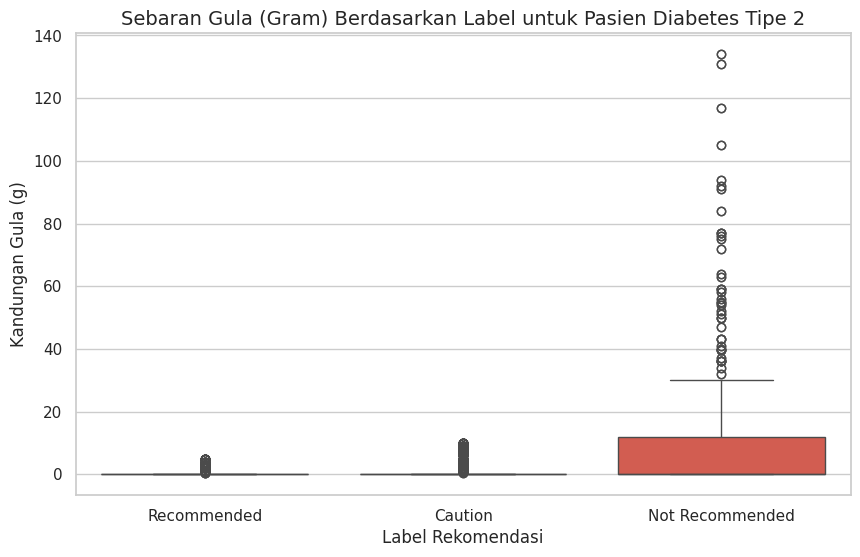

Insight: Produk yang mendapat label 'Recommended' untuk Tipe 2 memiliki median gula yang sangat rendah (mendekati 0). Sebaliknya, produk dengan label 'Not Recommended' rata-rata memiliki gula di atas 10g.


In [7]:
# Memfilter hanya untuk pasien Diabetes Tipe 2
df_t2 = df[df['diabetes_type'] == 2]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_t2, x='label', y='sugar_g', palette=custom_palette,
            order=['Recommended', 'Caution', 'Not Recommended'])

plt.title('Sebaran Gula (Gram) Berdasarkan Label untuk Pasien Diabetes Tipe 2', fontsize=14)
plt.xlabel('Label Rekomendasi')
plt.ylabel('Kandungan Gula (g)')
plt.show()

In [13]:

print("Insight: Produk yang mendapat label 'Recommended' untuk Tipe 2 memiliki median gula yang sangat rendah (mendekati 0). Sebaliknya, produk dengan label 'Not Recommended' rata-rata memiliki gula di atas 10g.")

Insight: Produk yang mendapat label 'Recommended' untuk Tipe 2 memiliki median gula yang sangat rendah (mendekati 0). Sebaliknya, produk dengan label 'Not Recommended' rata-rata memiliki gula di atas 10g.
